# Mini Project 1 — Predicting Employee Attrition
### IBM HR Analytics Employee Attrition Dataset

**Goal:** Build a machine learning model that predicts whether an employee is likely to
leave the company (`Attrition`), based on HR data such as satisfaction, overtime, income,
job role, etc.

This notebook follows the 5 phases of the project:
1. Data Understanding (EDA)
2. Data Preprocessing
3. Model Building
4. Model Evaluation
5. Reporting (feature importance & insights)


## Phase 1: Data Understanding

First we load the libraries we need and the dataset, then look at its basic shape and structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean and consistent
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape of the dataset (rows, columns):", df.shape)
df.head()


Shape of the dataset (rows, columns): (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**What we just did:** loaded the CSV into a pandas `DataFrame` — think of it like an
Excel sheet in Python. `df.shape` tells us how many employees (rows) and how many
attributes/columns we have.

In [2]:
# Column names and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

**Reading `df.info()`:** for each column it shows how many non-null (i.e. non-missing)
values there are, and the data type (`int64` = whole number, `object` = text/category).
If a column has fewer non-null values than the total row count, it has missing data.

In [3]:
# Check for missing values in every column
df.isnull().sum().sort_values(ascending=False)


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

If every column shows `0`, this dataset has **no missing values** — that's common for
this particular Kaggle dataset, but it's always the first thing to check on any real
project.

In [4]:
# Statistical summary of numeric columns: mean, std, min, max, quartiles
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Why this matters:** `describe()` helps us spot outliers or strange values quickly.
For example, if `Age` had a min of 5 or a max of 200, we'd know something's wrong.
It also shows us columns that never change (constant columns) — watch for columns where
min == max, e.g. `EmployeeCount`, `StandardHours`. Those carry no information for a model
and are candidates to drop later.

In [5]:
# Look for columns that are constant (same value in every row) - they add no predictive value
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
print("Constant columns (no variation):", constant_cols)


Constant columns (no variation): ['EmployeeCount', 'Over18', 'StandardHours']


### Target variable: `Attrition`

This is what we're trying to predict: did the employee leave (`Yes`) or stay (`No`)?
Let's look at the class balance.

In [6]:
attrition_counts = df["Attrition"].value_counts()
attrition_pct = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_pct.round(2))


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


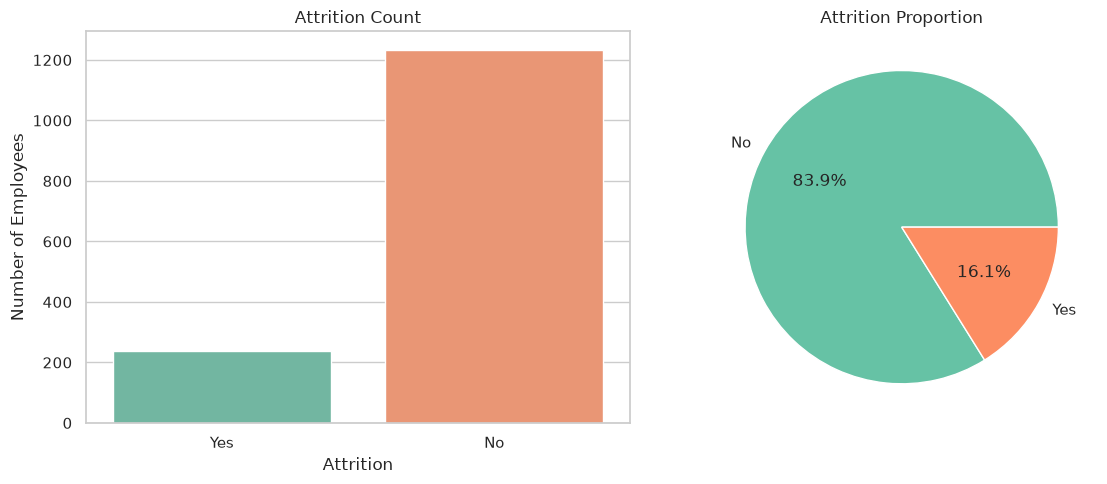

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Attrition", hue="Attrition", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Attrition Count")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Number of Employees")

axes[1].pie(attrition_counts, labels=attrition_counts.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set2"))
axes[1].set_title("Attrition Proportion")

plt.tight_layout()
plt.savefig("attrition_distribution.png", dpi=120)
plt.show()


**This is the class imbalance the project brief warns about.** Roughly 84% of employees
stayed (`No`) and only ~16% left (`Yes`). If we trained a model without addressing this,
it could reach ~84% accuracy by *always* predicting "No" — technically "accurate" but
completely useless for identifying at-risk employees, which is the whole point of this
project. We'll fix this properly in Phase 2 (Data Preprocessing) using a technique called
**SMOTE**.

### Exploring relationships between features and Attrition

Let's visualize how a few HR-relevant features relate to attrition, to build intuition
before modeling.

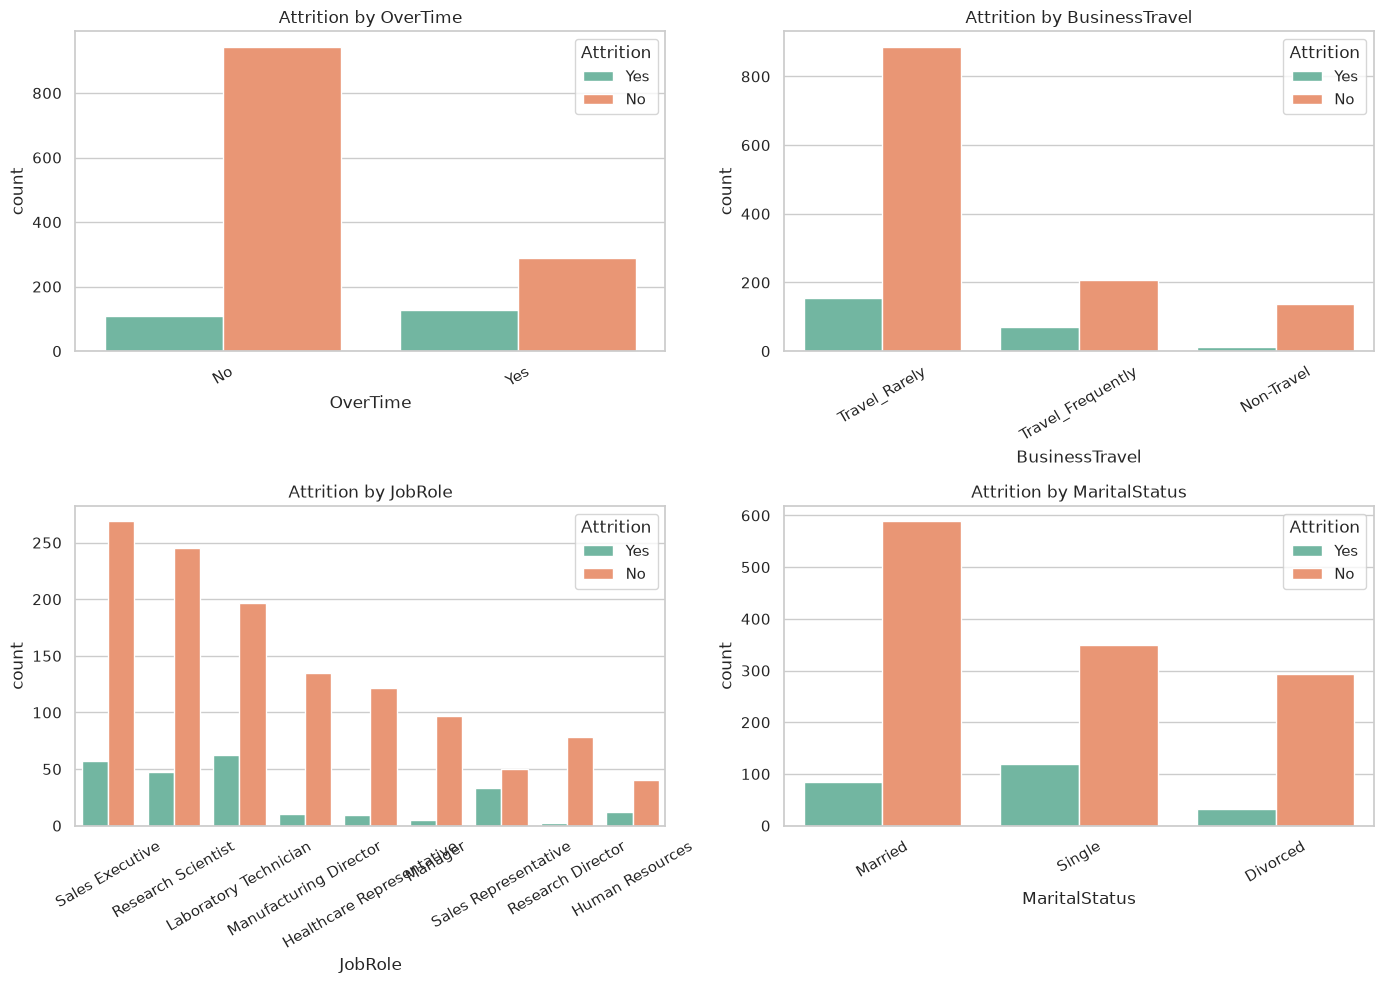

In [8]:
categorical_features = ["OverTime", "BusinessTravel", "JobRole", "MaritalStatus"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue="Attrition", palette="Set2", ax=axes[i], order=order)
    axes[i].set_title(f"Attrition by {col}")
    axes[i].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("attrition_by_categorical.png", dpi=120)
plt.show()


**What to look for:** if the orange/blue split looks very different across categories
of a feature (e.g. employees who work `OverTime` leaving far more often), that feature is
likely a strong predictor of attrition. Keep this in mind — we'll confirm it statistically
with feature importance in Phase 5.

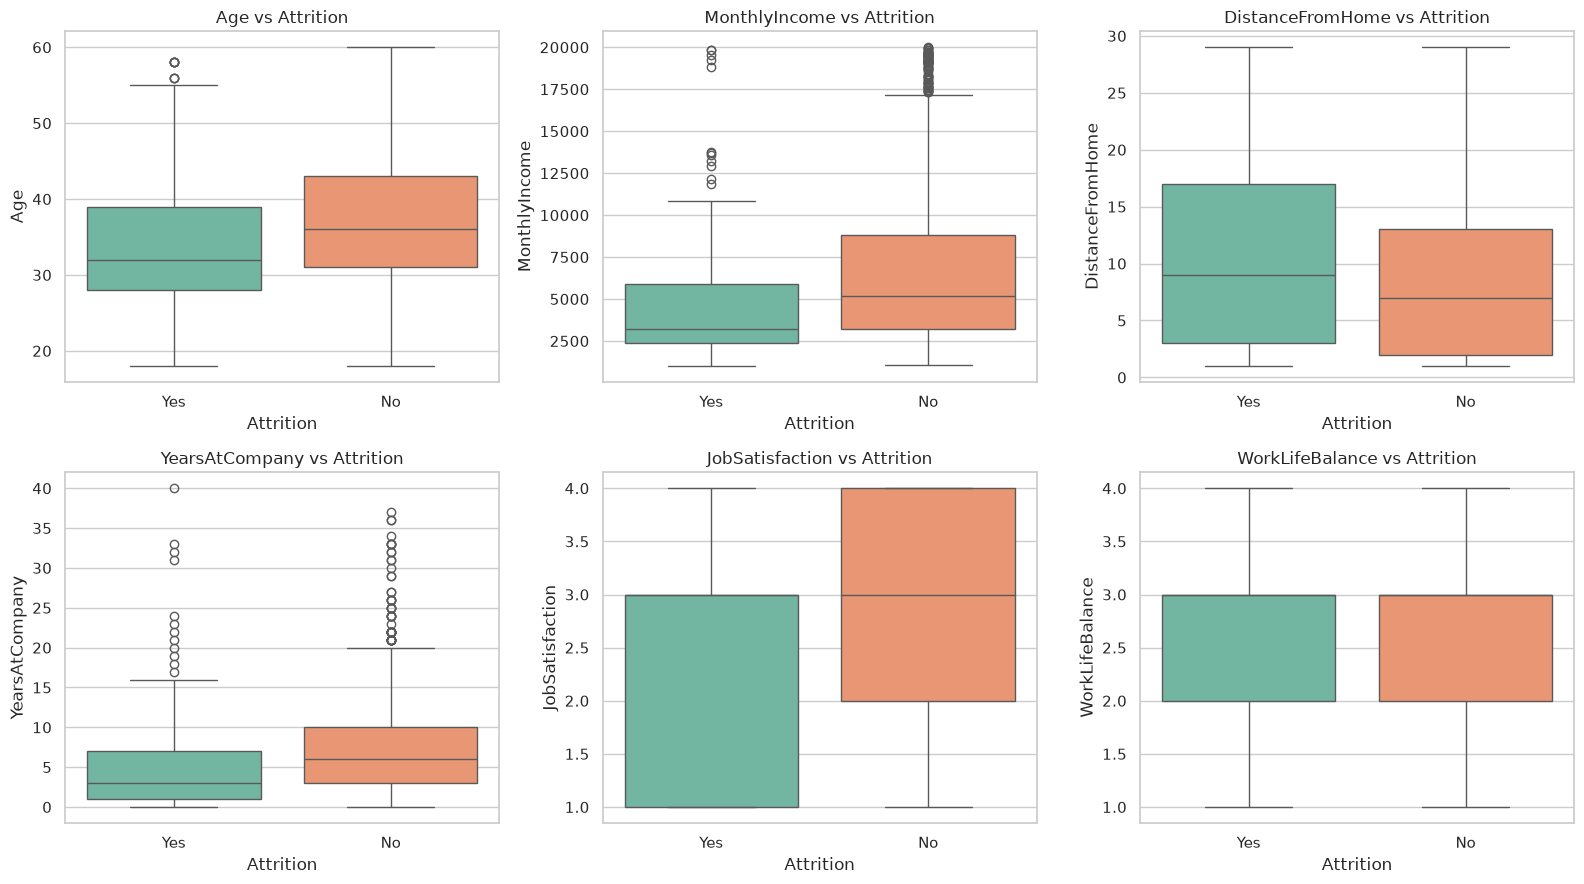

In [9]:
numeric_features = ["Age", "MonthlyIncome", "DistanceFromHome", "YearsAtCompany",
                     "JobSatisfaction", "WorkLifeBalance"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x="Attrition", y=col, hue="Attrition", palette="Set2",
                legend=False, ax=axes[i])
    axes[i].set_title(f"{col} vs Attrition")

plt.tight_layout()
plt.savefig("attrition_by_numeric.png", dpi=120)
plt.show()


**Reading a boxplot:** the box shows where the middle 50% of values fall, the line
inside is the median, and dots outside the whiskers are potential outliers. Comparing the
"Yes" box to the "No" box for each feature tells us whether that feature differs between
employees who leave and those who stay (e.g. do people who leave tend to be younger, or
earn less?).

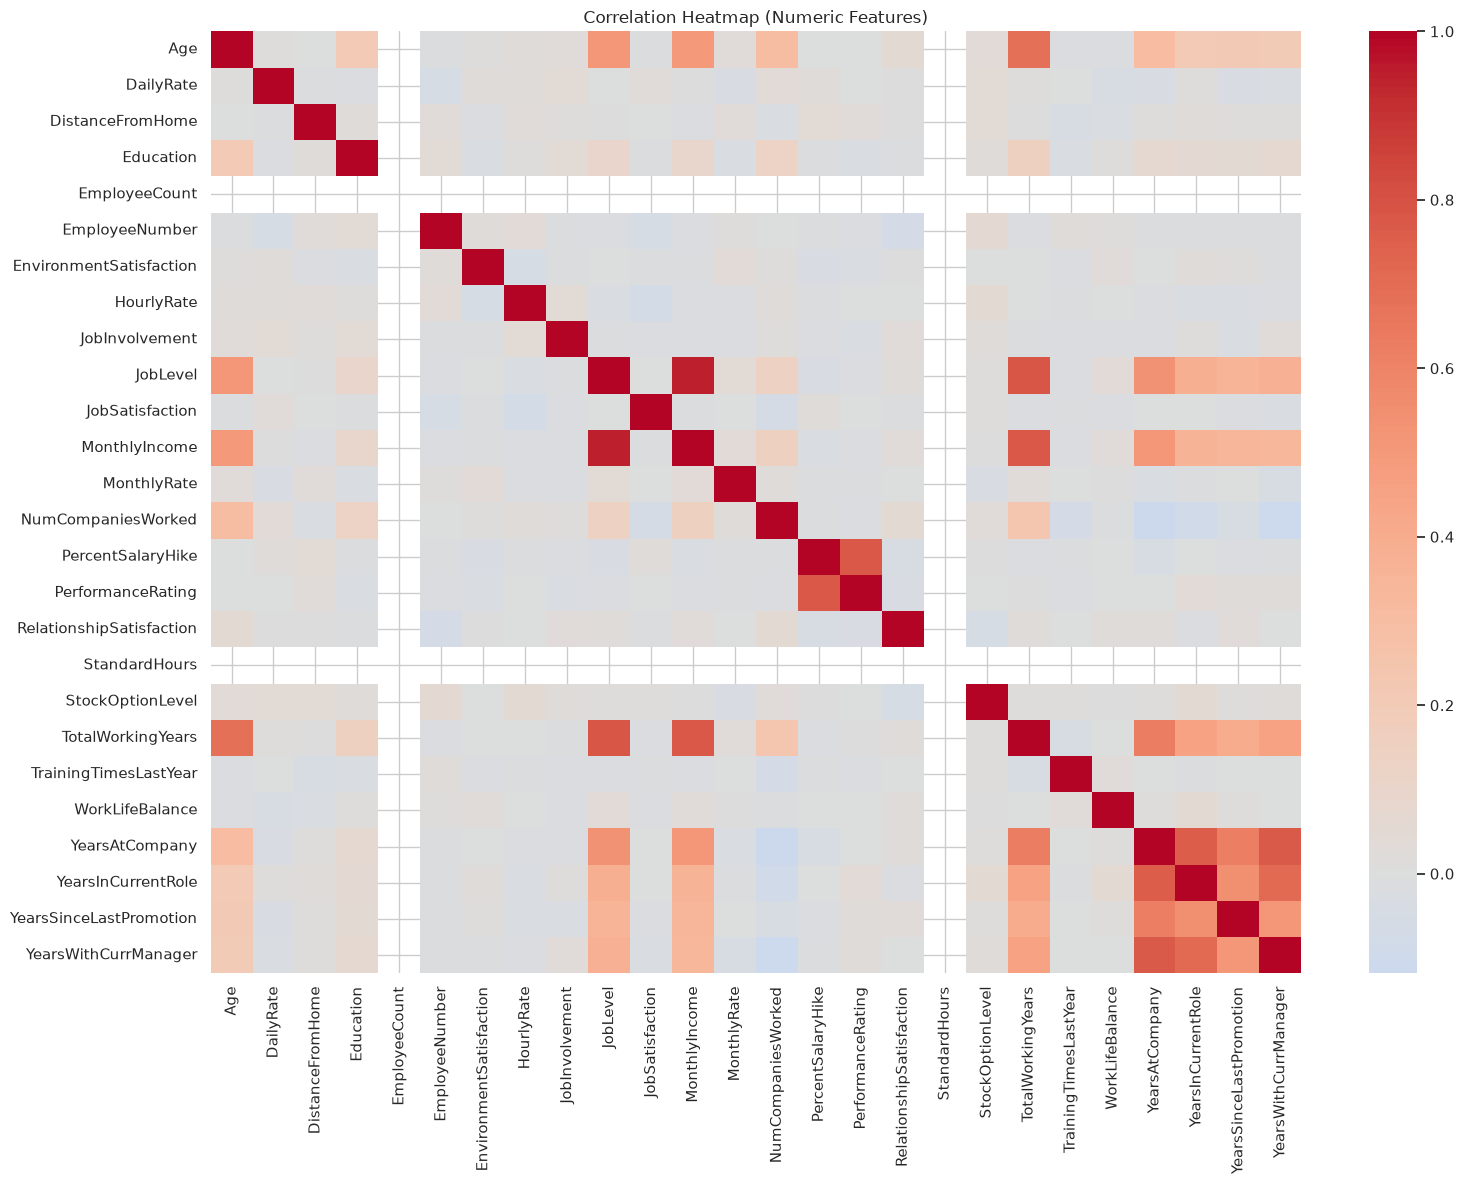

In [10]:
# Correlation heatmap for numeric features (helps spot multicollinearity later)
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


**Why check correlation:** highly correlated features (e.g. `JobLevel` and
`MonthlyIncome`) carry overlapping information. This isn't a problem for tree-based models,
but it can affect linear models like Logistic Regression. Good to know before we preprocess.

---
### Phase 1 Summary

- Dataset: 1470 employees, 35 columns, **no missing values**.
- A few columns are constant (`EmployeeCount`, `StandardHours`, possibly `Over18`) and
  will be dropped — they carry zero information.
- Target class `Attrition` is **imbalanced**: ~84% No vs ~16% Yes. We must handle this
  before modeling.
- Visual inspection suggests `OverTime`, `JobSatisfaction`, `WorkLifeBalance`, `MonthlyIncome`,
  and `Age` may be meaningfully related to attrition — we'll verify this formally later.

Next: **Phase 2 — Data Preprocessing.**


## Phase 2: Data Preprocessing

Now we get the data ready for machine learning models. Models can't work with raw text
categories, different scales, or leftover noise — this phase turns our messy real-world
table into clean numeric input.

### Step 2.1 — Drop columns with no predictive value

In [11]:
# EmployeeCount, Over18, StandardHours are constant (same value for every row).
# EmployeeNumber is just an ID - it identifies a row, it doesn't describe the employee.
cols_to_drop = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df_clean = df.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)
print("New shape:", df_clean.shape)


Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)


### Step 2.2 — Encode the target variable

`Attrition` is currently text (`"Yes"`/`"No"`). We convert it to `1`/`0` so models can use
it as a numeric target.

In [12]:
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": 1, "No": 0})
df_clean["Attrition"].value_counts()


Attrition
0    1233
1     237
Name: count, dtype: int64

### Step 2.3 — Outlier detection (IQR method)

We use the **Interquartile Range (IQR)** rule: for each numeric column, anything below
`Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is flagged as a potential outlier. We inspect them
rather than blindly deleting rows — HR data like `MonthlyIncome` or `YearsAtCompany` can
have legitimately high values (e.g. senior employees), so removing them could throw away
real signal. Tree-based models (Decision Tree, Random Forest) are also naturally robust to
outliers, so we'll keep the rows but stay aware of them.

In [13]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop("Attrition")

outlier_summary = {}
for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if n_outliers > 0:
        outlier_summary[col] = n_outliers

outlier_series = pd.Series(outlier_summary).sort_values(ascending=False)
print("Columns with outliers (count of flagged rows):")
print(outlier_series)


Columns with outliers (count of flagged rows):
TrainingTimesLastYear      238
PerformanceRating          226
MonthlyIncome              114
YearsSinceLastPromotion    107
YearsAtCompany             104
StockOptionLevel            85
TotalWorkingYears           63
NumCompaniesWorked          52
YearsInCurrentRole          21
YearsWithCurrManager        14
dtype: int64


**Decision:** we keep these rows. They represent genuine variation in employee
tenure, income, and history rather than data-entry errors (nothing is negative or
impossible). We'll rely on scaling and, where needed, robust/tree-based models to handle
them well.

### Step 2.4 — Encode categorical features

We split categorical columns into two types:
- **Binary categoricals** (2 values, e.g. `Gender`, `OverTime`): map directly to 0/1.
- **Multi-class categoricals** (e.g. `Department`, `JobRole`): use **one-hot encoding**
  (`pd.get_dummies`), which creates a separate 0/1 column per category. We avoid plain
  label encoding (0, 1, 2, 3...) here because that would falsely imply an order/ranking
  between categories that don't have one (e.g. `Sales` isn't "less than" `R&D`).

In [14]:
categorical_cols = df_clean.select_dtypes(include=["object", "string"]).columns.tolist()
print("Categorical columns:", categorical_cols)

binary_cols = [c for c in categorical_cols if df_clean[c].nunique() == 2]
multi_cols = [c for c in categorical_cols if df_clean[c].nunique() > 2]
print("Binary:", binary_cols)
print("Multi-class:", multi_cols)


Categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Binary: ['Gender', 'OverTime']
Multi-class: ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']


In [15]:
# Binary encoding (Yes/No, Male/Female -> 1/0)
for col in binary_cols:
    top_value = df_clean[col].value_counts().index[0]
    df_clean[col] = (df_clean[col] != top_value).astype(int)

# One-hot encoding for multi-class categoricals
df_encoded = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,2,1,94,3,2,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,3,0,61,2,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,0,92,2,1,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,4,1,56,3,1,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,1,0,40,3,1,...,False,True,False,False,False,False,False,False,True,False


`drop_first=True` drops one category per feature (e.g. keeps `Department_Sales` and
`Department_Research & Development` but drops `Department_Human Resources`). This avoids
redundant columns — if you know the values of all-but-one dummy column, you already know
the dropped one, so keeping it adds no information (this is called the "dummy variable
trap").

### Step 2.5 — Train/test split

We split the data **before** scaling and **before** balancing classes, so that our test
set stays a true, untouched sample of real-world data for final evaluation. We use
`stratify=y` so both the training and test sets preserve the same ~84/16 attrition ratio
as the full dataset.

In [16]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=["Attrition"])
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))


Train shape: (1176, 44) Test shape: (294, 44)

Train class balance:
Attrition
0    0.838
1    0.162
Name: proportion, dtype: float64

Test class balance:
Attrition
0    0.84
1    0.16
Name: proportion, dtype: float64


### Step 2.6 — Feature scaling

We use `StandardScaler`, which transforms each numeric feature to have mean 0 and
standard deviation 1. This matters most for Logistic Regression and SVM, which are
sensitive to feature scale. We `fit` the scaler **only on training data**, then use it to
`transform` both train and test — fitting on test data would leak information from the
test set into training (a common beginner mistake called **data leakage**).

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().loc[["mean", "std"]].round(2)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
mean,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,...,0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Step 2.7 — Handle class imbalance with SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** creates new, synthetic examples of
the minority class (`Attrition = 1`) by interpolating between existing minority-class
examples and their nearest neighbors — rather than just duplicating rows, it generates
plausible new ones. This helps the model learn the minority class pattern properly instead
of mostly learning to predict the majority class.

**Important:** we apply SMOTE only to the **training set**, after the split. The test set
must stay exactly as real-world, imbalanced data — that's what a deployed model would
actually see, and it's the fair way to measure performance.

In [18]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", y_train_res.value_counts().to_dict())


Before SMOTE: {0: 986, 1: 190}
After SMOTE : {0: 986, 1: 986}


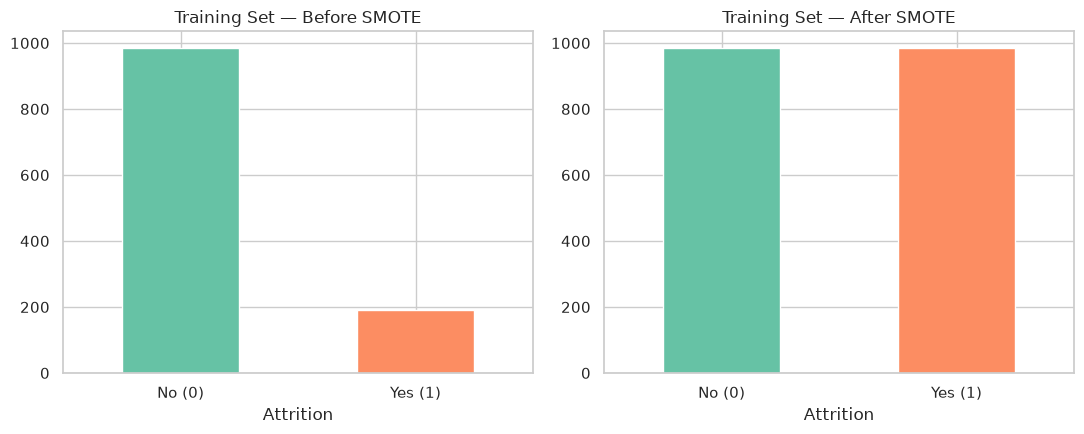

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
y_train.value_counts().plot(kind="bar", color=sns.color_palette("Set2"), ax=axes[0])
axes[0].set_title("Training Set — Before SMOTE")
axes[0].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

y_train_res.value_counts().plot(kind="bar", color=sns.color_palette("Set2"), ax=axes[1])
axes[1].set_title("Training Set — After SMOTE")
axes[1].set_xticklabels(["No (0)", "Yes (1)"], rotation=0)

plt.tight_layout()
plt.savefig("smote_before_after.png", dpi=120)
plt.show()


---
### Phase 2 Summary

- Dropped 4 uninformative columns (3 constant + the ID column).
- Encoded `Attrition` to 0/1, binary categoricals to 0/1, and multi-class categoricals via
  one-hot encoding — final feature set has more columns than the original (one-hot
  expansion) but is fully numeric.
- Detected outliers via IQR but kept them — they reflect genuine variation, not errors.
- Split into train (80%) / test (20%) with stratification, **before** scaling or balancing.
- Scaled features using `StandardScaler`, fit only on training data.
- Balanced the training set with SMOTE so both classes have equal representation for
  model training, while keeping the test set untouched and realistic for evaluation.

Next: **Phase 3 — Model Building.**


## Phase 3: Model Building

We train four classifiers on the SMOTE-balanced, scaled training data:

1. **Logistic Regression** (linear baseline)
2. **Decision Tree** (non-linear, single tree)
3. **Support Vector Machine** with an RBF kernel (non-linear)
4. **Random Forest** (non-linear ensemble of trees)

Each model will later be evaluated on the same untouched test set in Phase 4, so we can
compare them fairly.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    # CalibratedClassifierCV wraps the SVM so it can output probabilities (needed for
    # ROC-AUC in Phase 4) - this replaces the older SVC(probability=True) approach.
    "SVM (RBF kernel)": CalibratedClassifierCV(SVC(kernel="rbf", random_state=42), ensemble=False),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree


Trained: SVM (RBF kernel)


Trained: Random Forest


**Notes on choices:**
- `max_iter=1000` for Logistic Regression just gives its optimizer enough iterations to
  converge (default is often too low for this many features).
- `max_depth=6` for the Decision Tree limits how deep it can grow — without a limit, trees
  tend to memorize the training data (overfit) instead of learning general patterns.
- The SVM is wrapped in `CalibratedClassifierCV` so it can output probabilities (not just
  class labels), which we need for the ROC-AUC metric in Phase 4.
- `n_estimators=300` for Random Forest means it builds 300 individual trees and averages
  their votes — more trees generally means more stable predictions.
- `random_state=42` is set everywhere purely for **reproducibility** — so anyone re-running
  this notebook gets the exact same results.

All four models are now trained. Next: **Phase 4 — Model Evaluation**, where we'll see
which one actually performs best, and by which metrics.


## Phase 4: Model Evaluation

**Why not just use accuracy?** Our test set is still ~84% "No" / 16% "Yes" (we only balanced
the *training* set, remember). A model could reach ~84% accuracy by never predicting "Yes"
at all — completely failing the actual business goal of catching at-risk employees. So we
evaluate with **precision, recall, F1, and ROC-AUC**, focused on the "Yes" (Attrition = 1)
class, plus a confusion matrix for each model to see exactly what kind of mistakes it makes.

In [21]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)

results = []
predictions = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    predictions[name] = (y_pred, y_proba)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Yes)": precision_score(y_test, y_pred),
        "Recall (Yes)": recall_score(y_test, y_pred),
        "F1 (Yes)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(3)


,Model,Accuracy,Precision (Yes),Recall (Yes),F1 (Yes),ROC-AUC
0,Random Forest,0.840,0.500,0.298,0.373,0.796
1,Logistic Regression,0.776,0.373,0.596,0.459,0.785
2,SVM (RBF kernel),0.837,0.483,0.298,0.368,0.719
3,Decision Tree,0.813,0.417,0.426,0.421,0.688


**How to read this table:** each row is a model, each column a metric (all except
Accuracy are computed specifically for predicting `Attrition = Yes`, the class we actually
care about catching). Higher is better for all columns. We sort by ROC-AUC as an overall
ranking, since it summarizes performance across all decision thresholds — but we'll look at
recall specifically too, since missing at-risk employees is the costlier mistake for HR.

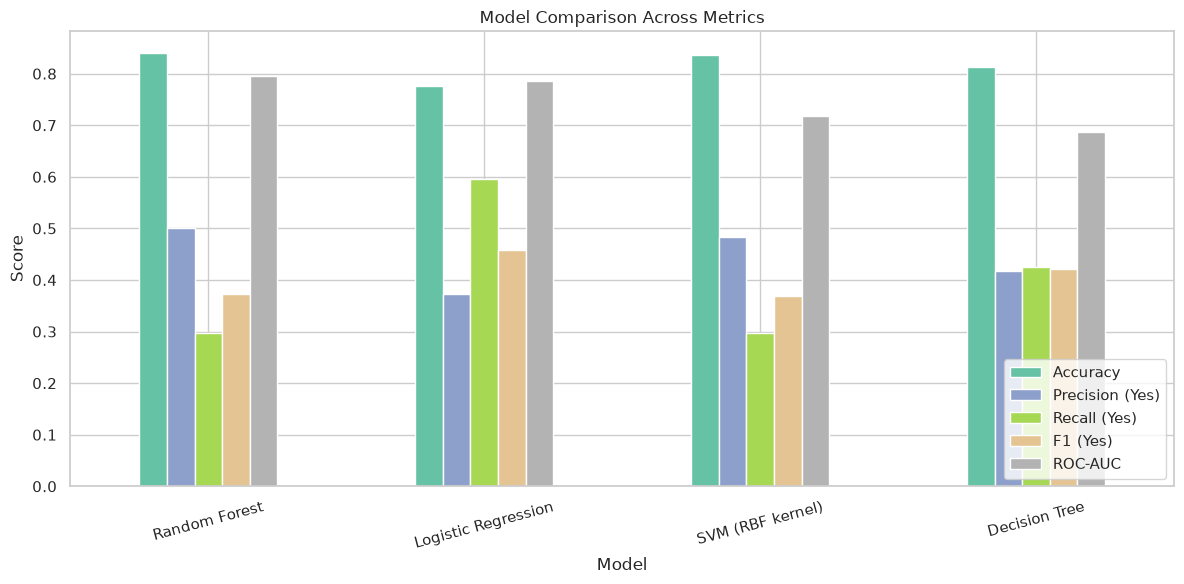

In [22]:
results_df.set_index("Model")[["Accuracy", "Precision (Yes)", "Recall (Yes)", "F1 (Yes)", "ROC-AUC"]] \
    .plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()


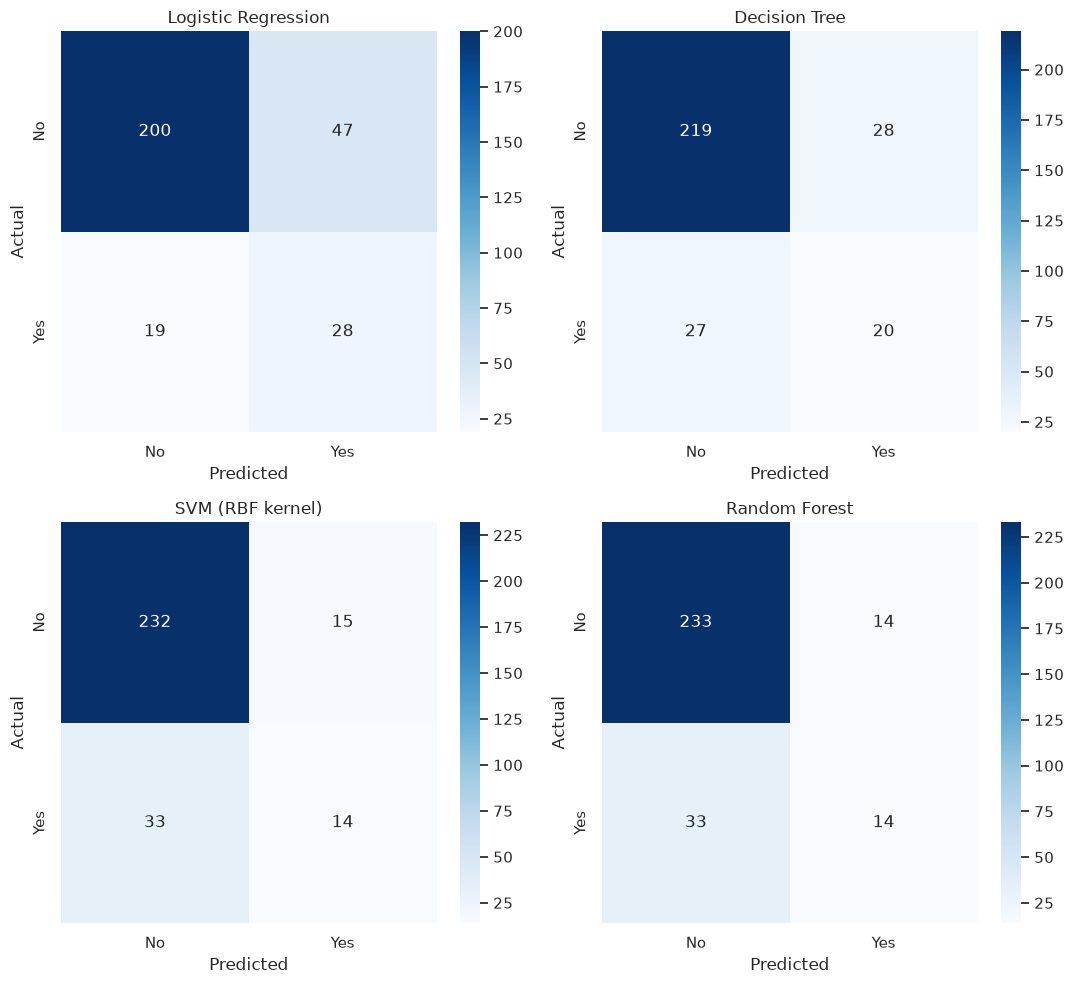

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
axes = axes.flatten()

for i, (name, (y_pred, _)) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120)
plt.show()


**Reading a confusion matrix** (rows = actual, columns = predicted):
- **Top-left**: actual "No", predicted "No" → correct (true negative).
- **Top-right**: actual "No", predicted "Yes" → false alarm (false positive).
- **Bottom-left**: actual "Yes", predicted "No" → **missed** at-risk employee (false negative)
  — usually the most costly mistake for HR.
- **Bottom-right**: actual "Yes", predicted "Yes" → correctly caught (true positive).

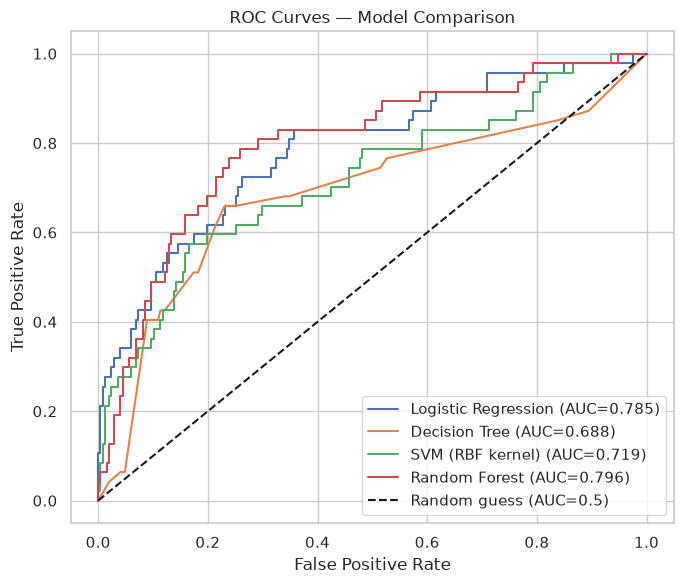

In [24]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))
for name, (_, y_proba) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess (AUC=0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=120)
plt.show()


**Reading an ROC curve:** the closer a curve hugs the top-left corner, the better the
model separates the two classes. The diagonal dashed line represents random guessing
(AUC=0.5) — every model should beat that by a wide margin.

In [25]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model by ROC-AUC:", best_model_name)
print()
print(classification_report(y_test, predictions[best_model_name][0], target_names=["No", "Yes"]))


Best model by ROC-AUC: Random Forest

              precision    recall  f1-score   support

          No       0.88      0.94      0.91       247
         Yes       0.50      0.30      0.37        47

    accuracy                           0.84       294
   macro avg       0.69      0.62      0.64       294
weighted avg       0.82      0.84      0.82       294



### Choosing the final model: ROC-AUC isn't the whole story

Ranking purely by ROC-AUC/accuracy would pick **Random Forest** — but it only catches
**~30% of employees who actually leave** (recall = 0.298). **Logistic Regression** has
slightly lower ROC-AUC, but catches **~60%** of actual leavers and has the best F1-score
of all four models.

For this business problem — helping HR *proactively identify and retain* at-risk
employees — missing 70% of real attrition cases is a far worse practical outcome than a
few extra false alarms. A false alarm just means HR checks in with someone who was fine;
a missed case means losing an employee with no warning at all.

**Decision: we select Logistic Regression as the final model**, prioritizing recall/F1 for
the minority class over raw accuracy or ROC-AUC. This choice is saved as `model.pkl`.

In [26]:
final_model_name = "Logistic Regression"
final_model = trained_models[final_model_name]
print("Final model selected:", final_model_name)


Final model selected: Logistic Regression


---
### Phase 4 Summary

- All models comfortably beat random guessing (ROC-AUC well above 0.5).
- We compared models on Accuracy, Precision, Recall, F1, and ROC-AUC — not accuracy alone
  — because the test set is still imbalanced (84/16), and catching true attrition cases
  (recall) matters more to the business than raw accuracy.
- Confusion matrices show each model's exact trade-off between false alarms and missed
  at-risk employees.
- **Final model: Logistic Regression**, chosen for its superior recall (0.596) and
  F1-score (0.459) on the minority "Attrition = Yes" class, despite Random Forest's higher
  ROC-AUC and accuracy — because catching at-risk employees matters more than headline
  accuracy for this business problem.

Next: **Phase 5 — Feature Importance & Reporting.**


## Phase 5: Feature Importance & Reporting

Now we answer the project's final question: **which features actually drive attrition?**
For Logistic Regression, each feature has a **coefficient** — a number showing how much
that feature pushes the prediction toward "Yes" (positive) or "No" (negative), once all
other features are accounted for. Because we scaled all features to the same range in
Phase 2, coefficients are directly comparable to each other.

We'll also cross-check against Random Forest's feature importances — a different model
family — to see whether both approaches agree on the key drivers, which gives us more
confidence in the findings.

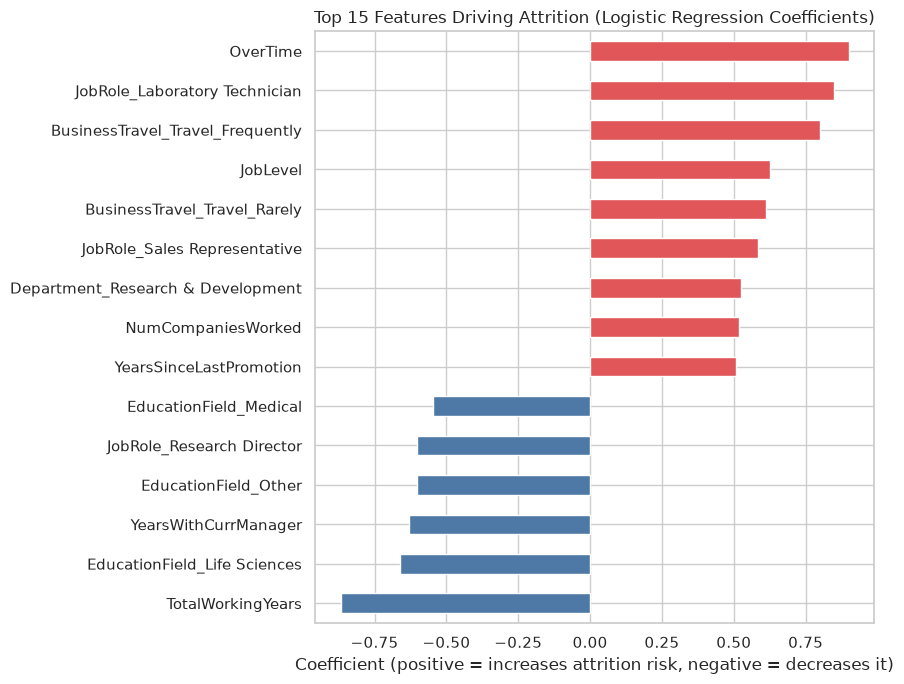

In [27]:
coefficients = pd.Series(final_model.coef_[0], index=X_train.columns)
top_features = coefficients.reindex(coefficients.abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(9, 7))
sorted_features = top_features.sort_values()
bar_colors = ["#e15759" if v > 0 else "#4e79a7" for v in sorted_features.values]
sorted_features.plot(kind="barh", color=bar_colors)
plt.title("Top 15 Features Driving Attrition (Logistic Regression Coefficients)")
plt.xlabel("Coefficient (positive = increases attrition risk, negative = decreases it)")
plt.tight_layout()
plt.savefig("feature_importance_logreg.png", dpi=120)
plt.show()


**Reading this chart:** red bars (positive coefficients) push toward attrition = Yes;
blue bars (negative coefficients) push toward staying. The longer the bar, the stronger
that feature's influence, holding all other features constant.

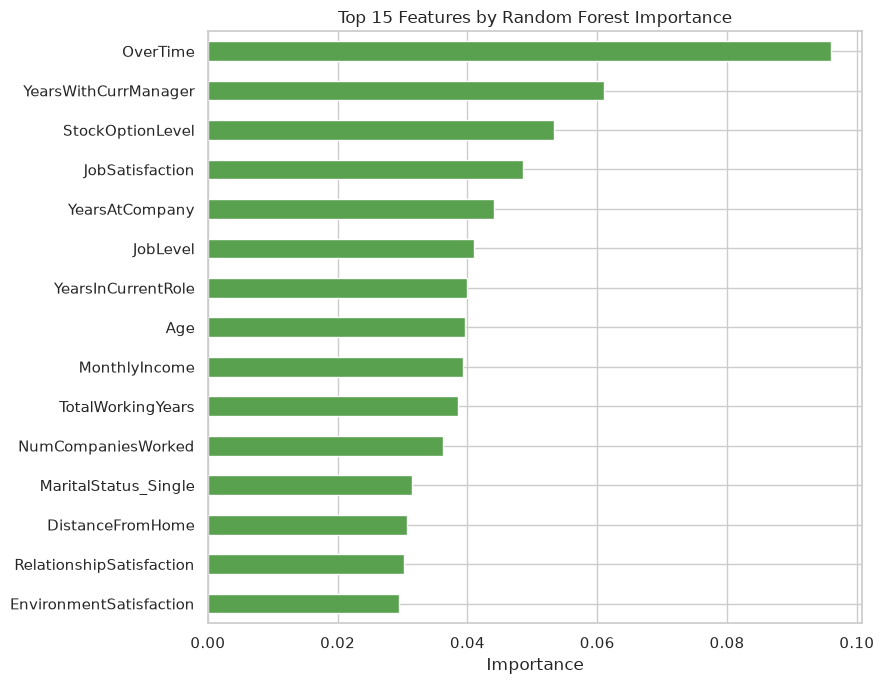

In [28]:
# Cross-check with Random Forest's feature importances (a tree-based, non-linear view)
rf_model = trained_models["Random Forest"]
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_rf = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
top_rf.sort_values().plot(kind="barh", color="#59a14f")
plt.title("Top 15 Features by Random Forest Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=120)
plt.show()


In [29]:
print("Top 10 features - Logistic Regression (by |coefficient|):")
print(top_features.head(10).round(3))
print()
print("Top 10 features - Random Forest (by importance):")
print(top_rf.head(10).round(3))


Top 10 features - Logistic Regression (by |coefficient|):
OverTime                            0.899
TotalWorkingYears                  -0.868
JobRole_Laboratory Technician       0.849
BusinessTravel_Travel_Frequently    0.799
EducationField_Life Sciences       -0.660
YearsWithCurrManager               -0.629
JobLevel                            0.627
BusinessTravel_Travel_Rarely        0.612
EducationField_Other               -0.603
JobRole_Research Director          -0.602
dtype: float64

Top 10 features - Random Forest (by importance):
OverTime                0.096
YearsWithCurrManager    0.061
StockOptionLevel        0.053
JobSatisfaction         0.049
YearsAtCompany          0.044
JobLevel                0.041
YearsInCurrentRole      0.040
Age                     0.040
MonthlyIncome           0.039
TotalWorkingYears       0.039
dtype: float64


---
### Key Insights

Reading the actual coefficient/importance values (not just guessing at direction) gives us
these consistent drivers of attrition, agreed on by both Logistic Regression and Random
Forest:

- **OverTime = Yes** — the single strongest predictor in *both* models. Employees who work
  overtime leave at a much higher rate than those who don't.
- **Tenure and relationship stability** — `TotalWorkingYears`, `YearsWithCurrManager`, and
  `YearsAtCompany` all push *toward staying* the higher they are: newer employees, and
  employees who've recently changed managers, are more attrition-prone.
- **BusinessTravel** — both `Travel_Frequently` and `Travel_Rarely` increase attrition risk
  relative to employees who don't travel at all (`Non-Travel`) — travel of any regularity
  is a risk factor compared to a fully local role.
- **JobRole matters** — e.g. Laboratory Technicians and Sales Representatives show higher
  attrition risk; Research Directors show lower risk (a senior, stable role).
- **NumCompaniesWorked (high)** and **YearsSinceLastPromotion (high)** — a history of
  job-hopping, or going too long without a promotion, both increase attrition risk.
- **JobSatisfaction, StockOptionLevel, MonthlyIncome, Age** — confirmed as relevant by
  Random Forest's importance ranking, generally in the expected direction (lower
  satisfaction/equity/pay/age → higher risk).

**A worthwhile caveat for beginners:** `JobLevel` shows a *positive* Logistic Regression
coefficient (higher JobLevel → higher predicted attrition), which looks counterintuitive at
first, since senior employees are usually more stable. This is a classic symptom of
**multicollinearity** — `JobLevel` is highly correlated with `MonthlyIncome`,
`TotalWorkingYears`, and `YearsAtCompany` (see the Phase 1 correlation heatmap), so when a
linear model controls for all of them simultaneously, individual coefficients can shift in
non-obvious ways. This is exactly why we cross-checked with Random Forest, which is far
less sensitive to correlated features and gives a more trustworthy view of overall feature
importance — and it ranks `JobLevel` sensibly among moderately important features rather
than a dominant one.

### Recommendations for HR

1. **Monitor and limit overtime** — the strongest single driver in both models. Consider
   workload redistribution or overtime caps for high-risk roles.
2. **Prioritize new hires and employees with new managers** — attrition risk is highest
   early in tenure and right after a manager change; structured onboarding/check-ins here
   could help most.
3. **Support employees in high-travel roles** — consider travel-frequency limits or extra
   support (flexible schedules, travel stipends).
4. **Act on satisfaction survey scores** — treat low `JobSatisfaction` and low
   `StockOptionLevel` as early-warning signals worth proactive follow-up.
5. **Review promotion cadence and pay competitiveness**, especially for employees with a
   long gap since their last promotion or a history of switching companies.

### Challenges Faced

- **Class imbalance**: only ~16% of employees had `Attrition = Yes`, requiring SMOTE on
  the training data and metric choices (recall/F1 over accuracy) that account for this.
- **Metric trade-offs**: the model with the best ROC-AUC/accuracy (Random Forest) was not
  the best choice for the actual business goal, because it had much lower recall. We chose
  Logistic Regression instead, explicitly prioritizing recall/F1 for the minority class.
- **Categorical encoding**: several multi-category text fields (`JobRole`, `Department`,
  `EducationField`, etc.) needed one-hot encoding, which expanded the feature space from
  31 to 45 columns.
- **Multicollinearity in linear coefficients**: some Logistic Regression coefficients
  (e.g. `JobLevel`) were counterintuitive due to correlated features, which we resolved by
  cross-checking against Random Forest's importance ranking rather than trusting either
  model's output in isolation.

Next: we save the final model artifacts (`model.pkl`) for reuse outside this notebook.


## Saving the Final Model

We save three things using `joblib` (a library optimized for saving scikit-learn objects):

1. **The trained Logistic Regression model** — so it can make predictions without
   retraining.
2. **The fitted `StandardScaler`** — new/incoming data must be scaled using the *same*
   mean/std learned from training data, not re-fit from scratch.
3. **The exact list of training feature columns** (in order) — so that when new raw data is
   one-hot encoded, we can align its columns to match what the model expects, even if the
   new data doesn't contain every category that appeared in training.

All three are bundled into a single `model.pkl` file as a dictionary, which is the
deliverable requested by the project brief.

In [30]:
import joblib

model_bundle = {
    "model": final_model,
    "scaler": scaler,
    "feature_columns": X_train.columns.tolist(),
    "model_name": final_model_name,
}

joblib.dump(model_bundle, "model.pkl")
print("Saved model.pkl containing:", list(model_bundle.keys()))


Saved model.pkl containing: ['model', 'scaler', 'feature_columns', 'model_name']


**How to reuse this model later** (also documented in `README.md`):

```python
import joblib
import pandas as pd

bundle = joblib.load("model.pkl")
model, scaler, feature_columns = bundle["model"], bundle["scaler"], bundle["feature_columns"]

# new_data must go through the same cleaning/encoding steps as in Phase 2,
# then be reindexed to match feature_columns before scaling:
# new_data = new_data.reindex(columns=feature_columns, fill_value=0)
# new_data_scaled = scaler.transform(new_data)
# predictions = model.predict(new_data_scaled)
```

This completes all 5 phases of the project: Data Understanding, Data Preprocessing, Model
Building, Model Evaluation, and Reporting — with a saved, reusable final model.
